 Personalized Medical Recommendation System with Machine Learning

Description

In [67]:
import pandas as pd
df= pd.read_csv(r'C:\Users\Jimmy\Downloads\Training.csv')
print('done')

done


In [68]:
df.head()

,itching,skin_rash,nodal_skin_eruptions,continuous_sneezing,shivering,chills,joint_pain,stomach_pain,acidity,ulcers_on_tongue,...,blackheads,scurring,skin_peeling,silver_like_dusting,small_dents_in_nails,inflammatory_nails,blister,red_sore_around_nose,yellow_crust_ooze,prognosis
0,1,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
1,0,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
2,1,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
3,1,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
4,1,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection


In [69]:
df.shape

(4920, 133)

In [70]:
df['prognosis'].unique()

array(['Fungal infection', 'Allergy', 'GERD', 'Chronic cholestasis',
       'Drug Reaction', 'Peptic ulcer diseae', 'AIDS', 'Diabetes ',
       'Gastroenteritis', 'Bronchial Asthma', 'Hypertension ', 'Migraine',
       'Cervical spondylosis', 'Paralysis (brain hemorrhage)', 'Jaundice',
       'Malaria', 'Chicken pox', 'Dengue', 'Typhoid', 'hepatitis A',
       'Hepatitis B', 'Hepatitis C', 'Hepatitis D', 'Hepatitis E',
       'Alcoholic hepatitis', 'Tuberculosis', 'Common Cold', 'Pneumonia',
       'Dimorphic hemmorhoids(piles)', 'Heart attack', 'Varicose veins',
       'Hypothyroidism', 'Hyperthyroidism', 'Hypoglycemia',
       'Osteoarthristis', 'Arthritis',
       '(vertigo) Paroymsal  Positional Vertigo', 'Acne',
       'Urinary tract infection', 'Psoriasis', 'Impetigo'], dtype=object)

In [71]:
len(df['prognosis'].unique())

41

In [72]:
# ecoding prognonsis
le = LabelEncoder()
le.fit(y)
Y = le.transform(y)

In [73]:
Y

array([15, 15, 15, ..., 38, 35, 27])

TRAIN TEST SPLIT

In [74]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

In [75]:
X = dataset.drop('prognosis', axis=1)
y = dataset['prognosis']
print('done')

done


In [76]:
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.3, random_state=20)

In [77]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((3444, 132), (1476, 132), (3444,), (1476,))

TRANING THE TOP MODELS

In [78]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, confusion_matrix
import numpy as np
print('done')


done


In [79]:
#CREATING A DICTIONARY TO STORE MODELS
models = {
    'SVC': SVC(kernel='linear'),
    'RandomForest': RandomForestClassifier(n_estimators=100, random_state=42),
    'GradientBoosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
    'KNeighbors': KNeighborsClassifier(n_neighbors=5),
    'MultinomialNB': MultinomialNB()
}
for model_name, model in models.items():
    #train model
    model.fit(X_train,y_train)

    #test model
    predictions= model.predict(X_test)

    #calculate the accuracy score
    accuracy = accuracy_score(y_test, predictions)

    #calculate the confusion matrix
    cm = confusion_matrix(y_test, predictions)
    print(f"{model_name} accuracy : {accuracy}")
    print(f"{model_name} Confusion Matrix:")
    print(np.array2string(cm, separator=', '))

    
    

SVC accuracy : 1.0
SVC Confusion Matrix:
[[40,  0,  0, ...,  0,  0,  0],
 [ 0, 43,  0, ...,  0,  0,  0],
 [ 0,  0, 28, ...,  0,  0,  0],
 ...,
 [ 0,  0,  0, ..., 34,  0,  0],
 [ 0,  0,  0, ...,  0, 41,  0],
 [ 0,  0,  0, ...,  0,  0, 31]]
RandomForest accuracy : 1.0
RandomForest Confusion Matrix:
[[40,  0,  0, ...,  0,  0,  0],
 [ 0, 43,  0, ...,  0,  0,  0],
 [ 0,  0, 28, ...,  0,  0,  0],
 ...,
 [ 0,  0,  0, ..., 34,  0,  0],
 [ 0,  0,  0, ...,  0, 41,  0],
 [ 0,  0,  0, ...,  0,  0, 31]]
GradientBoosting accuracy : 1.0
GradientBoosting Confusion Matrix:
[[40,  0,  0, ...,  0,  0,  0],
 [ 0, 43,  0, ...,  0,  0,  0],
 [ 0,  0, 28, ...,  0,  0,  0],
 ...,
 [ 0,  0,  0, ..., 34,  0,  0],
 [ 0,  0,  0, ...,  0, 41,  0],
 [ 0,  0,  0, ...,  0,  0, 31]]
KNeighbors accuracy : 1.0
KNeighbors Confusion Matrix:
[[40,  0,  0, ...,  0,  0,  0],
 [ 0, 43,  0, ...,  0,  0,  0],
 [ 0,  0, 28, ...,  0,  0,  0],
 ...,
 [ 0,  0,  0, ..., 34,  0,  0],
 [ 0,  0,  0, ...,  0, 41,  0],
 [ 0,  0,  0, ...,

In [80]:
 #all the models are perfect , as all are 0 which means perfect model

SINGLE MODEL PREDICTION

In [81]:
# selecting svc
svc = SVC(kernel='linear')
svc.fit(X_train,y_train)
ypred = svc.predict(X_test)
accuracy_score(y_test,ypred)

1.0

In [82]:
#saving model
import pickle 
pickle.dump(svc,open("minor project/svc.pkl", "wb"))

In [83]:
# load model
svc = pickle.load(open("minor project/svc.pkl",'rb'))

In [84]:
# test 1:
print("predicted disease :",svc.predict(X_test.iloc[0].values.reshape(1,-1)))
print("Actual Disease :", y_test[0])

predicted disease : [40]
Actual Disease : 40


C:\Users\Jimmy\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


In [85]:
# test 2:
print("predicted disease :",svc.predict(X_test.iloc[20].values.reshape(1,-1)))
print("Actual Disease :", y_test[20])

predicted disease : [10]
Actual Disease : 10


C:\Users\Jimmy\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


visualizing the actual and the predicted price

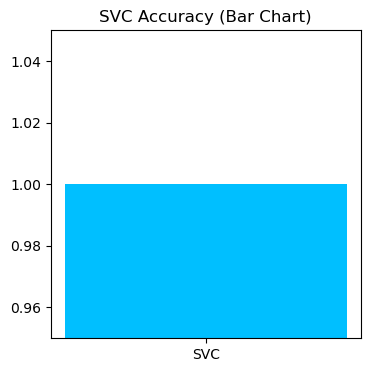

In [97]:
import matplotlib.pyplot as plt
svc_preds = svc.predict(X_test)
svc_acc = accuracy_score(y_test, svc_preds)

plt.figure(figsize=(4, 4))
plt.bar(['SVC'], [svc_acc], color='deepskyblue')
plt.title('SVC Accuracy (Bar Chart)')
plt.ylim(0.95, 1.05)
plt.show()

In [105]:
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import MultinomialNB


rf = RandomForestClassifier()
rf.fit(X_train, y_train)

gb = GradientBoostingClassifier()
gb.fit(X_train, y_train)

knn = KNeighborsClassifier()
knn.fit(X_train, y_train)

nb = MultinomialNB()
nb.fit(X_train, y_train)

MultinomialNB()

In [107]:
print(svc)
print(rf)
print(gb)
print(knn)
print(nb)

SVC(kernel='linear')
RandomForestClassifier()
GradientBoostingClassifier()
KNeighborsClassifier()
MultinomialNB()


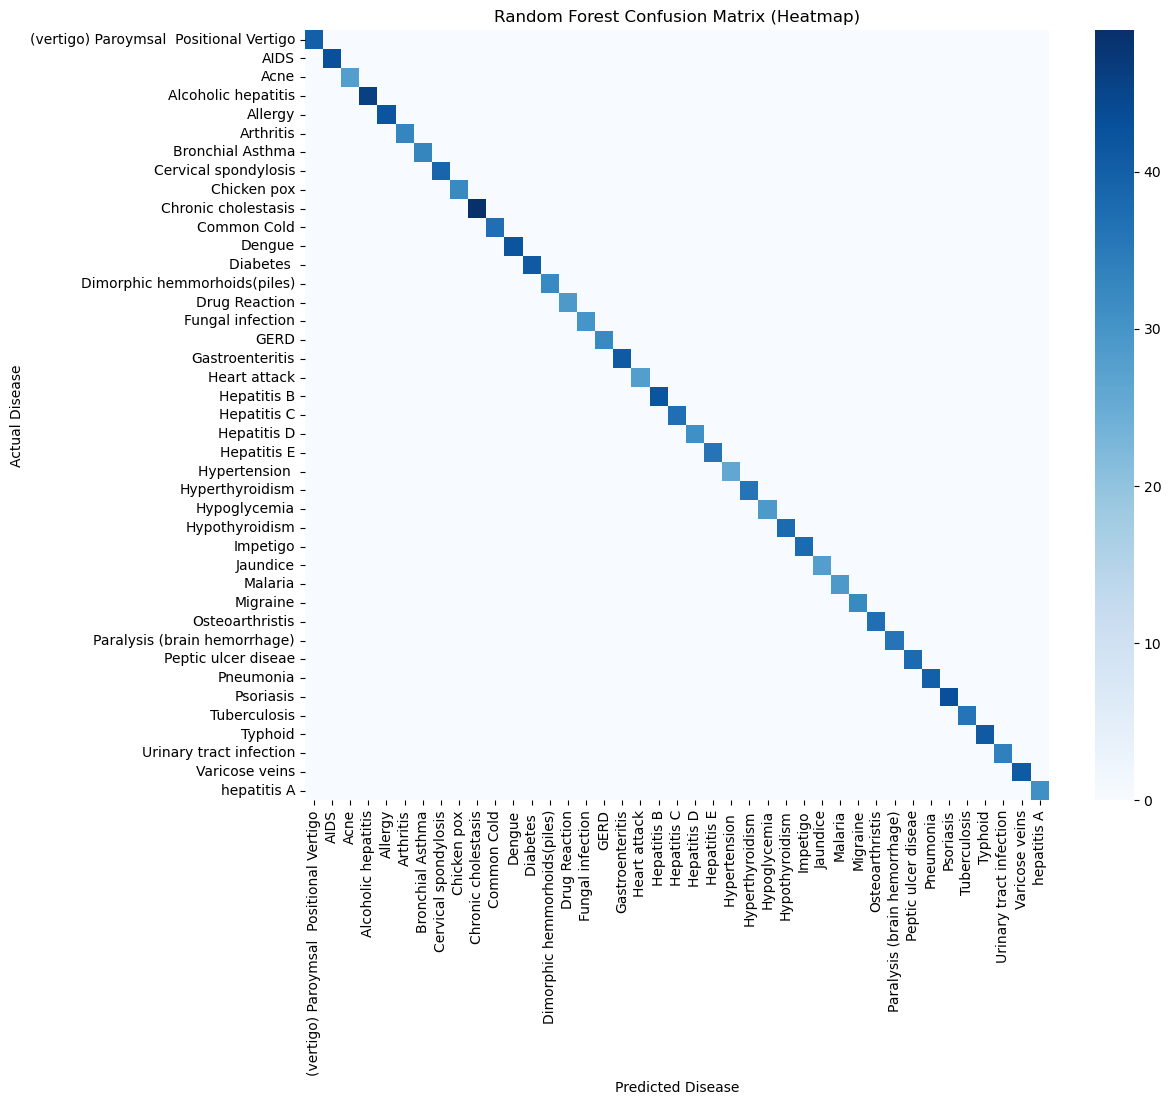

In [109]:
# Agar label encoder used hai, to disease names le lo
disease_labels = le.inverse_transform(list(set(y_test)))
plt.figure(figsize=(12,10))  # Graph ko bada karo
sns.heatmap(rf_cm, cmap='Blues', annot=False, xticklabels=disease_labels, yticklabels=disease_labels)
plt.title('Random Forest Confusion Matrix (Heatmap)')
plt.xlabel('Predicted Disease')
plt.ylabel('Actual Disease')
plt.show()

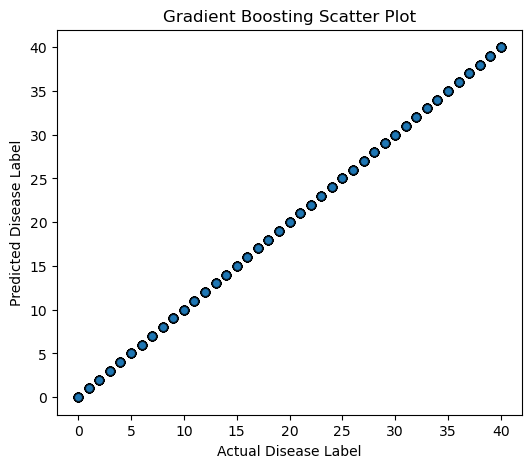

In [110]:
gb_preds = gb.predict(X_test)

plt.figure(figsize=(6, 5))
plt.scatter(y_test, gb_preds, alpha=0.6, edgecolors='black')
plt.title('Gradient Boosting Scatter Plot')
plt.xlabel('Actual Disease Label')
plt.ylabel('Predicted Disease Label')
plt.show()

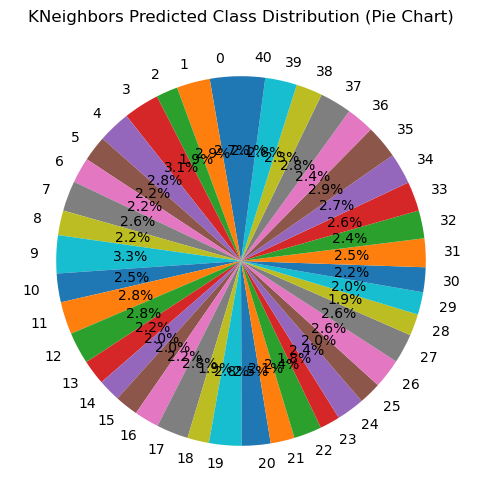

In [111]:
import numpy as np

knn_preds = knn.predict(X_test)
labels, counts = np.unique(knn_preds, return_counts=True)

plt.figure(figsize=(6, 6))
plt.pie(counts, labels=labels, autopct='%1.1f%%', startangle=90)
plt.title('KNeighbors Predicted Class Distribution (Pie Chart)')
plt.show()

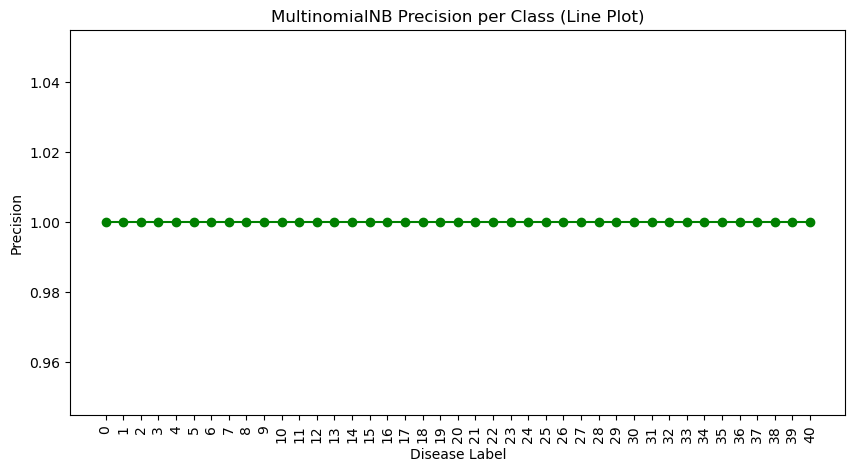

In [112]:
from sklearn.metrics import classification_report

nb_preds = nb.predict(X_test)
report = classification_report(y_test, nb_preds, output_dict=True)
class_labels = [label for label in report if label.isdigit()]
class_precisions = [report[label]["precision"] for label in class_labels]

plt.figure(figsize=(10, 5))
plt.plot(class_labels, class_precisions, marker='o', color='green')
plt.title('MultinomialNB Precision per Class (Line Plot)')
plt.xlabel('Disease Label')
plt.ylabel('Precision')
plt.xticks(rotation=90)
plt.show()

In [122]:
import pickle

rf = pickle.load(open('minor project/best_rf_model.pkl', 'rb'))
le = pickle.load(open('minor project/rf_label_encoder.pkl', 'rb'))

input_symptoms = [0]*132  
if rf.n_features_in_ != len(input_symptoms):
    raise Exception(f"input_symptoms ki length ({len(input_symptoms)}) aur model ki expected ({rf.n_features_in_}) !")

pred_label = rf.predict([input_symptoms])[0]
pred_disease = le.inverse_transform([pred_label])[0]
print("Predicted Disease:", pred_disease)

Predicted Disease: Dimorphic hemmorhoids(piles)


C:\Users\Jimmy\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
